In [2]:
import pandas as pd
import glob
import os
import jdatetime

def convert_persian_to_english_numbers(text):
    """تبدیل اعداد یونیکد فارسی به انگلیسی با مدیریت مقادیر تهی"""
    if pd.isna(text) or str(text).strip() == "" or str(text).lower() == "nan":
        return str(pd.NaT)
    persian_nums = '۰۱۲۳۴۵۶۷۸۹'
    english_nums = '0123456789'
    translation_table = str.maketrans(persian_nums, english_nums)
    return str(text).translate(translation_table)

def parse_date(date_str, is_native):
    """تبدیل هوشمند تاریخ با مدیریت مقادیر Float و NaN"""
    if pd.isna(date_str) or str(date_str).strip() == "" or str(date_str).lower() == "nan":
        return pd.NaT
    try:
        if is_native:
            en_date = convert_persian_to_english_numbers(date_str)
            if en_date == str(pd.NaT):
                return pd.NaT
            # تبدیل به string قبل از split برای جلوگیری از خطای float
            date_part = str(en_date).split()[0]
            j_date = jdatetime.datetime.strptime(date_part, '%Y/%m/%d')
            return pd.to_datetime(j_date.togregorian())
        else:
            return pd.to_datetime(date_str, errors='coerce')
    except Exception as e:
        return pd.NaT

raw_data_dir = '../data/raw/'
all_csv_files = glob.glob(os.path.join(raw_data_dir, '*.csv'))

if not all_csv_files:
    print("هیچ فایلی یافت نشد.")
else:
    print(f"شروع پردازش {len(all_csv_files)} فایل با استخراج آمار توصیفی (Describe/Info)...")
    macro_stats = []
    
    for filepath in all_csv_files:
        filename = os.path.basename(filepath)
        is_native = 'native' in filename or 'cafebazaar' in filename
        ecosystem = 'Global' if not is_native else 'Native'
        lang = 'en_us' if '_en_us' in filename else 'fa_ir'
        
        parts = filename.replace('.csv', '').split('_')
        chatbot_name = parts[2] if 'balanced' in filename or 'native' in filename else parts[0]
        
        try:
            df = pd.read_csv(filepath)
            
            # 1. اعمال پارسر تاریخ اختصاصی
            df['parsed_date'] = df['full_date'].apply(lambda x: parse_date(x, is_native))
            
            # 2. استخراج اطلاعات توصیفی متن با جایگزینی مقادیر Null
            df['text_length'] = df['content'].fillna('').astype(str).apply(lambda x: len(x.split()))
            avg_words = round(df['text_length'].mean(), 1)
            
            # 3. محاسبات مرکزی
            total_reviews = len(df)
            avg_score = round(df['score'].mean(), 2)
            std_score = round(df['score'].std(), 2)
            
            min_date = df['parsed_date'].min().strftime('%Y-%m-%d') if not pd.isnull(df['parsed_date'].min()) else 'N/A'
            max_date = df['parsed_date'].max().strftime('%Y-%m-%d') if not pd.isnull(df['parsed_date'].max()) else 'N/A'
            
            macro_stats.append({
                'Ecosystem': ecosystem,
                'Chatbot': chatbot_name,
                'Total_Reviews': total_reviews,
                'Avg_Words_per_Comment': avg_words,
                'Mean_Score': avg_score,
                'Score_Std_Dev': std_score,
                'Start_Date': min_date,
                'End_Date': max_date
            })
            
        except Exception as e:
            print(f"خطا در {filename}: {e}")

    # نمایش خروجی نهایی
    stats_df = pd.DataFrame(macro_stats)
    stats_df = stats_df.sort_values(by=['Ecosystem', 'Mean_Score'], ascending=[True, False]).reset_index(drop=True)
    
    print("\n=== جدول آمار توصیفی کلان (Macro-Descriptive Statistics) ===")
    display(stats_df)

شروع پردازش 18 فایل با استخراج آمار توصیفی (Describe/Info)...

=== جدول آمار توصیفی کلان (Macro-Descriptive Statistics) ===


,Ecosystem,Chatbot,Total_Reviews,Avg_Words_per_Comment,Mean_Score,Score_Std_Dev,Start_Date,End_Date
0,Global,Copilot,7962,5.4,4.63,1.03,2025-11-10,2026-04-27
1,Global,Grok,2556,5.1,4.61,1.07,2025-11-01,2026-04-21
2,Global,ChatGPT,6000,4.3,4.60,1.07,2025-11-26,2026-04-25
3,Global,Perplexity,415,4.5,4.60,1.02,2025-11-01,2026-04-22
4,Global,Grok,34005,8.3,4.52,1.16,2025-11-15,2026-04-27
5,Global,Copilot,22383,11.0,4.49,1.13,2025-11-01,2026-04-27
6,Global,DeepSeek,2385,9.1,4.38,1.26,2025-11-01,2026-04-27
7,Global,ChatGPT,26029,6.7,4.37,1.27,2025-11-28,2026-04-25
8,Global,Gemini,6344,4.2,4.35,1.38,2025-11-01,2026-04-27
9,Global,Gemini,36000,5.4,4.29,1.35,2025-11-28,2026-04-25


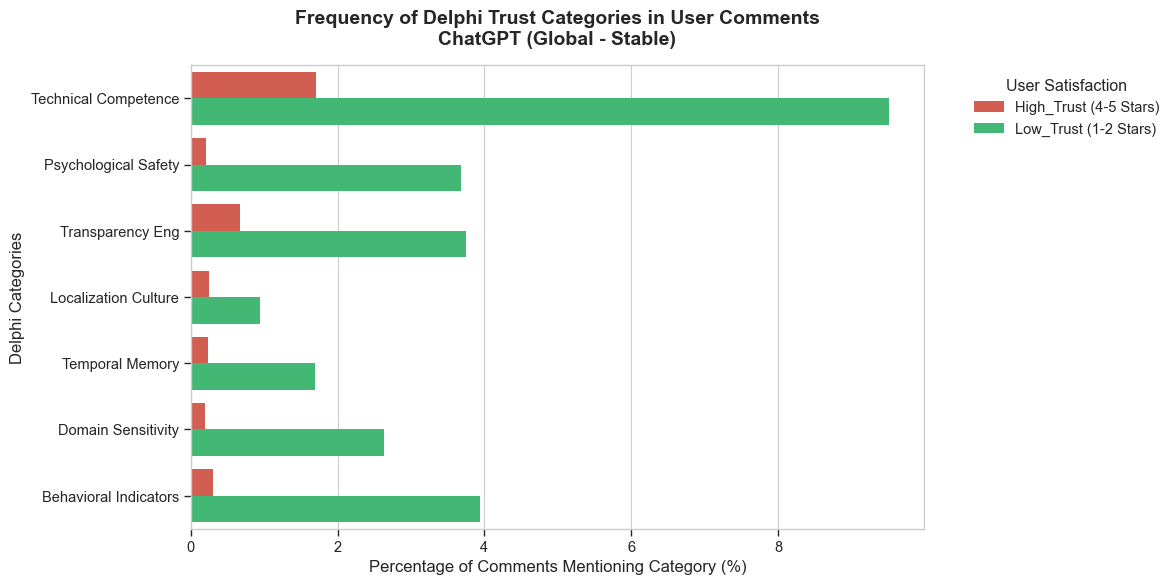

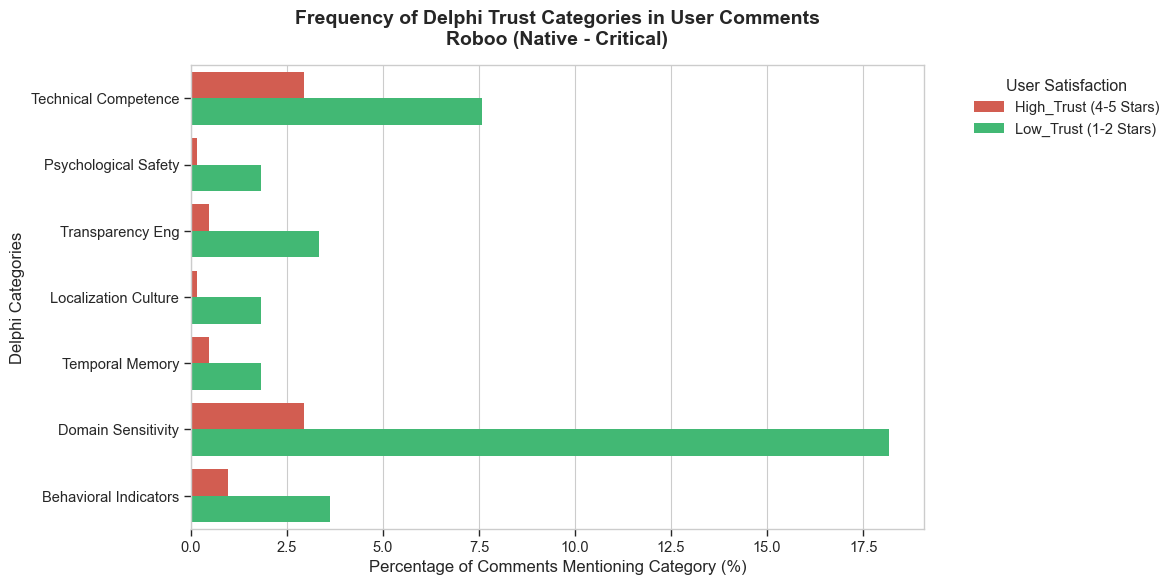

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# تنظیم استایل آکادمیک برای نمودارها
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# ۱. تعریف واژه‌نامه برای ۷ مقوله اصلی دلفی
DELPHI_CATEGORIES = {
    'Technical_Competence': {
        'en': ['fast', 'slow', 'accurate', 'wrong', 'error', 'bug', 'hallucinat', 'lag', 'crash'],
        'fa': ['دقت', 'درست', 'سرعت', 'هنگ', 'غلط', 'اشتباه', 'توهم', 'کند', 'قطعی', 'خراب']
    },
    'Psychological_Safety': {
        'en': ['security', 'privacy', 'hack', 'steal', 'data', 'safe', 'protect'],
        'fa': ['امنیت', 'هک', 'اطلاعات', 'حریم', 'خصوصی', 'دزدی', 'رمز', 'امن']
    },
    'Transparency_Eng': {
        'en': ['source', 'reference', 'explain', 'reason', 'transparent', 'cite', 'why'],
        'fa': ['شفاف', 'منبع', 'رفرنس', 'دلیل', 'چرا', 'توضیح', 'استناد']
    },
    'Localization_Culture': {
        'en': ['tone', 'rude', 'polite', 'culture', 'language', 'persian', 'respect'],
        'fa': ['لحن', 'بی‌ادب', 'محترمانه', 'فرهنگ', 'ایران', 'فارسی', 'زبان', 'ادب']
    },
    'Temporal_Memory': {
        'en': ['memory', 'remember', 'forget', 'history', 'context', 'previous'],
        'fa': ['حافظه', 'یادش', 'فراموش', 'قبلا', 'تاریخچه', 'گذشته']
    },
    'Domain_Sensitivity': {
        'en': ['medical', 'bank', 'money', 'finance', 'risk', 'sensitive', 'health'],
        'fa': ['پزشکی', 'بانک', 'پول', 'بیمار', 'مالی', 'خطر', 'حساس']
    },
    'Behavioral_Indicators': {
        'en': ['trust', 'rely', 'believe', 'copy', 'accept', 'uninstall'],
        'fa': ['کپی', 'اعتماد', 'مطمئن', 'استفاده', 'قبول', 'حذف', 'پاک']
    }
}

def categorize_trust(score):
    """تبدیل ستاره‌ها به کلاس‌های رضایت برای ایجاد کنتراست"""
    if score in [1, 2]:
        return 'Low_Trust (1-2 Stars)'
    elif score in [4, 5]:
        return 'High_Trust (4-5 Stars)'
    else:
        return 'Neutral'

def count_category_mentions(df, lang_code):
    """اسکن متون برای یافتن کلیدواژه‌های ۷ مقوله"""
    results = []
    
    # فیلتر کردن نظرات خنثی برای ایجاد تضاد بهتر در نمودار
    df = df[df['Trust_Level'] != 'Neutral'].copy()
    
    for category, keywords in DELPHI_CATEGORIES.items():
        words = keywords['en'] if lang_code == 'en_us' else keywords['fa']
        
        # بررسی وجود هر یک از کلیدواژه‌ها در متن
        pattern = '|'.join(words)
        df[category] = df['content'].astype(str).str.lower().str.contains(pattern, case=False, na=False)
        
        # محاسبه درصد تکرار در بین کاربران راضی و ناراضی
        grouped = df.groupby('Trust_Level')[category].mean() * 100
        
        for trust_level, percentage in grouped.items():
            results.append({
                'Category': category.replace('_', ' '),
                'Trust_Level': trust_level,
                'Mention_Percentage': percentage
            })
            
    return pd.DataFrame(results)

def plot_eda_charts():
    # مسیر فایل‌های دو نقطه افراطی
    files = {
        'ChatGPT (Global - Stable)': ('../data/raw/balanced_data_ChatGPT_en_us.csv', 'en_us'),
        'Roboo (Native - Critical)': ('../data/raw/native_data_Roboo_cafebazaar.csv', 'fa_ir')
    }
    
    for name, (filepath, lang) in files.items():
        try:
            df = pd.read_csv(filepath)
            df['Trust_Level'] = df['score'].apply(categorize_trust)
            
            # استخراج آمار
            stats_df = count_category_mentions(df, lang)
            
            # رسم نمودار
            plt.figure(figsize=(12, 6))
            sns.barplot(data=stats_df, x='Mention_Percentage', y='Category', hue='Trust_Level', palette=['#e74c3c', '#2ecc71'])
            
            plt.title(f'Frequency of Delphi Trust Categories in User Comments\n{name}', fontsize=14, pad=15, fontweight='bold')
            plt.xlabel('Percentage of Comments Mentioning Category (%)', fontsize=12)
            plt.ylabel('Delphi Categories', fontsize=12)
            plt.legend(title='User Satisfaction', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            
            # ذخیره و نمایش
            filename_safe = name.split(' ')[0]
            plt.savefig(f'../logs/EDA_{filename_safe}_7Categories.png', dpi=300, bbox_inches='tight')
            plt.show()
            
        except Exception as e:
            print(f"خطا در پردازش {name}: {e}")

# اجرای عملیات رسم نمودارها
plot_eda_charts()